In [1]:
from graphviz import Digraph

dot = Digraph(comment='Fluxograma GERMoR')

# Estilos
dot.attr('node', shape='box', style='filled', fillcolor='lightblue', fontname='Arial', fontsize='10')
dot.node('start', 'Início', shape='oval', fillcolor='darkgreen', fontcolor='white', style='filled,bold', fontsize='12')

# Nós principais (retângulos com texto resumido para clareza)
dot.node('A', 'Receber as NF´s, Boletos e Demonstrativos dos fornecedores\nvia E-mail oficial de Políticas.')
dot.node('B', 'Registrar o recebimento na planilha de Controle.xlsx')
dot.node('C', 'Salvar no Sharepoint da área GERMOR, na pasta Ano/Mes do NF.')
dot.node('D', 'Encaminhar via Docusign apenas a NF para a gestão assinar.')
dot.node('E', 'Conferir via Docusign se a NF foi assinada pela gestão.')
dot.node('F', 'A gestão assinou as NF´s no Docusign?')

dot.node('G', 'Salvar a versão das NF´s assinadas pela gestão no Sharepoint')
dot.node('H', 'Criar o Parecer com as informações das NF´s, Boletos, Demonstrativos e Suporte Rateio.')

dot.node('I', 'Foi criado o Parecer?')
dot.node('J', 'Disponibilizar para revisão do Parecer ao Especialista da área de Políticas de Crédito.')

dot.node('K', 'O Parecer foi revisado?')
dot.node('L', 'Registrar na planilha Controle de Pagamentos.xlsx')
dot.node('M', 'Salvar a versão do Parecer assinado pela gestão no Sharepoint.')

dot.node('N', 'O Parecer foi assinado pela gestão?')
dot.node('O', 'Conferir via Docusign se o Parecer foi assinado pela gestão.')
dot.node('P', 'Encaminhar via Docusign para a gestão assinar o Parecer sobre pagamentos.')

dot.node('Q', 'Foi cadastrado no Power List?')
dot.node('R', 'Criar novo item no Power List anexando NF, Boleto e Parecer do fornecedor.')

dot.node('S', 'Controle de Revisão (Double-check)')
dot.node('T', 'Comunicar time de Governança de TI sobre pagamento e vencimento da NF.')

dot.node('U', 'Time de Governança foi comunicado?')
dot.node('V', 'Verificar com time de Governança se pagamento ocorreu junto ao time Financeiro.')

dot.node('W', 'As NF´s foram pagas?')
dot.node('X', 'Registrar na planilha Controle.xlsx a data que foi paga.')

dot.node('Y', 'Realizar acompanhamento de gastos da GERMOR.')
dot.node('Z', 'A visão no Power BI foi atualizada?')
dot.node('AA', 'Atualizar o Power BI do Diário de Bordo para a liderança.')
dot.node('AB', 'Inserir no Diário de Bordo as principais oscilações e atrasos.')

# Conexões
dot.edge('start', 'A')
dot.edge('A', 'B')
dot.edge('B', 'C')
dot.edge('C', 'D')
dot.edge('D', 'E')
dot.edge('E', 'F')

dot.edge('F', 'G', label='SIM')
dot.edge('F', 'start', label='NÃO', constraint='false', style='dashed')

dot.edge('G', 'H')
dot.edge('H', 'I')
dot.edge('I', 'J', label='NÃO')
dot.edge('I', 'K', label='SIM')

dot.edge('J', 'K')
dot.edge('K', 'L', label='SIM')
dot.edge('K', 'J', label='NÃO', style='dashed')

dot.edge('L', 'M')
dot.edge('M', 'N')
dot.edge('N', 'O', label='NÃO')
dot.edge('N', 'L', label='SIM', style='dashed')

dot.edge('O', 'P')
dot.edge('P', 'N')

dot.edge('Q', 'R', label='NÃO')
dot.edge('Q', 'S', label='SIM')

dot.edge('R', 'L')

dot.edge('S', 'T')
dot.edge('T', 'U')

dot.edge('U', 'V', label='SIM')
dot.edge('U', 'start', label='NÃO', style='dashed')

dot.edge('V', 'W')
dot.edge('W', 'X', label='SIM')
dot.edge('W', 'start', label='NÃO', style='dashed')

dot.edge('Y', 'Z', label='SIM')
dot.edge('Y', 'start', label='NÃO', style='dashed')

dot.edge('Z', 'AA', label='NÃO')
dot.edge('AA', 'AB')

# Gerar arquivo PDF do fluxograma
dot.render('fluxograma_germor', format='pdf', view=True)


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

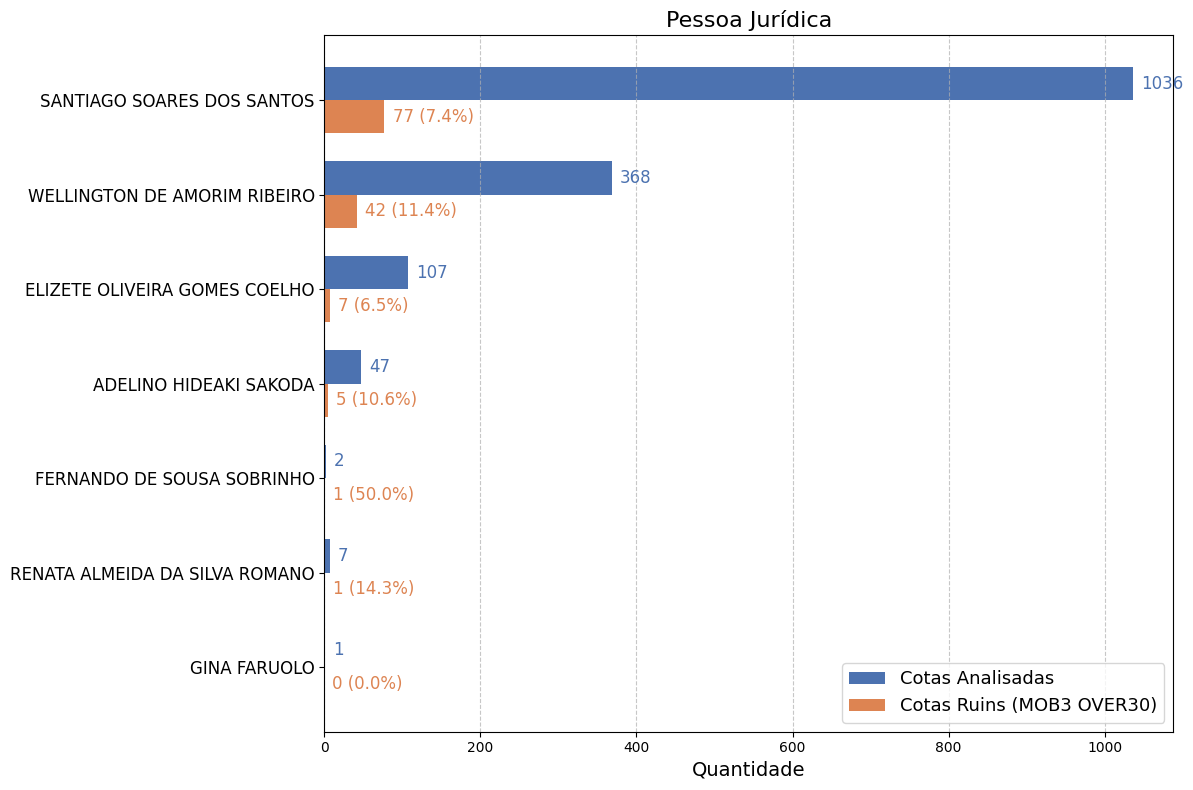

In [17]:
import matplotlib.pyplot as plt
import numpy as np

usuarios = [
    "FERNANDO DE SOUSA SOBRINHO",
    "RENATA ALMEIDA DA SILVA ROMANO",
    "WELLINGTON DE AMORIM RIBEIRO",
    "ADELINO HIDEAKI SAKODA",
    "SANTIAGO SOARES DOS SANTOS",
    "ELIZETE OLIVEIRA GOMES COELHO",
    "GINA FARUOLO"
]

cotas_analisadas = [2, 7, 368, 47, 1036, 107, 1]
cotas_ruins = [1, 1, 42, 5, 77, 7, 0]
percentuais = [50.0, 14.3, 11.4, 10.6, 7.4, 6.5, 0.0]

# Ordenar por cotas ruins (decrescente)
dados = list(zip(usuarios, cotas_analisadas, cotas_ruins, percentuais))
dados_ordenados = sorted(dados, key=lambda x: x[2], reverse=True)

usuarios_ord, cotas_analisadas_ord, cotas_ruins_ord, percentuais_ord = zip(*dados_ordenados)

y_pos = np.arange(len(usuarios_ord))
altura_barra = 0.35

plt.figure(figsize=(12,8))

bars1 = plt.barh(y_pos - altura_barra/2, cotas_analisadas_ord, height=altura_barra, label='Cotas Analisadas', color='#4C72B0')
bars2 = plt.barh(y_pos + altura_barra/2, cotas_ruins_ord, height=altura_barra, label='Cotas Ruins (MOB3 OVER30)', color='#DD8452')

plt.yticks(y_pos, usuarios_ord, fontsize=12)
plt.xlabel('Quantidade', fontsize=14)
plt.title('Pessoa Jurídica', fontsize=16)

plt.grid(axis='x', linestyle='--', alpha=0.7)

# Rótulos nas barras cotas analisadas (todos valores)
for bar in bars1:
    width = bar.get_width()
    plt.text(width + max(cotas_analisadas_ord)*0.01, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', va='center', fontsize=12, color='#4C72B0')

# Rótulos nas barras cotas ruins (todos valores, inclusive zero)
for i, bar in enumerate(bars2):
    width = bar.get_width()
    plt.text(width + max(cotas_analisadas_ord)*0.01, bar.get_y() + bar.get_height()/2,
             f'{int(width)} ({percentuais_ord[i]:.1f}%)', va='center', fontsize=12, color='#DD8452')

plt.legend(fontsize=13)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


